# Fitting a fringed planet spectrum

This notebook is a follow-up to [`fit_continuum.ipynb`](fit_continuum.ipynb). It shows how to forward-model **fringing** on a medium-resolution 1000 K spectrum using `splinenorm`.

We show the modelling of a toy fringe pattern on a medium-resolution dataset (JWST/NIRSpec G395H spectrum of HD 19467 B after PSF subtraction).

Examples of fringing patterns in real datasets are reported in the literature (e.g. [Horstman et al. 2025](https://ui.adsabs.harvard.edu/abs/2024SPIE13096E..2EH/abstract))

**Workflow**
1. Load the planet template for one NIRSpec detector (NRS1 by default).
2. Build a supersampled fringe pattern and inject it.
3. Fit a spline-modulated planet forward model with `SplineModel` and `solve_linear`.
4. Recover the fringe envelope and the planetary spectrum.

Detector split: **NRS1** for λ < 4.1 µm, **NRS2** for λ ≥ 4.1 µm.

In [108]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from splinenorm.functions import solve_linear
from splinenorm.spline_model import SplineModel

%matplotlib inline

## 1. Load the planet template

The file `data/HD19467B_spectrum_bestfit_model.txt` contains the JWST/NIRSpec G395H retrieval spectrum. We use column 4 (`bestfit_model`) and select one detector.

In [109]:
DATA_DIR = Path("../data")
PLANET_MODEL_FILE = DATA_DIR / "HD19467B_spectrum_bestfit_model.txt"
DETECTOR_SPLIT_UM = 4.1
DETECTOR = 1  # 1 = NRS1, 2 = NRS2


def load_planet_spectrum(detector: int = 1) -> tuple[np.ndarray, np.ndarray]:
    planet_data = np.loadtxt(PLANET_MODEL_FILE, comments="#")
    wavelength = planet_data[:, 0]
    planet_flux = planet_data[:, 3]
    if detector == 1:
        mask = wavelength < DETECTOR_SPLIT_UM
    else:
        mask = wavelength >= DETECTOR_SPLIT_UM
    return wavelength[mask], planet_flux[mask]


wavelength, planet_flux = load_planet_spectrum(detector=DETECTOR)
finite = np.isfinite(planet_flux)
planet_template = np.nan_to_num(planet_flux, nan=0.0)
nrs = f"NRS{DETECTOR}"

print(f"{nrs}: {wavelength.size} pixels, {wavelength.min():.3f}–{wavelength.max():.3f} µm")
print(f"Finite pixels: {finite.sum()}")

NRS1: 1790 pixels, 2.871–4.083 µm
Finite pixels: 1790


## 2. Build and inject the IFU fringe pattern

Fringes are a multiplicative sinc-smoothed cosine on a **supersampled wavelength grid**. The sinc damping increases with wavelength (stronger smoothing at long λ), then the pattern is interpolated onto the data grid.

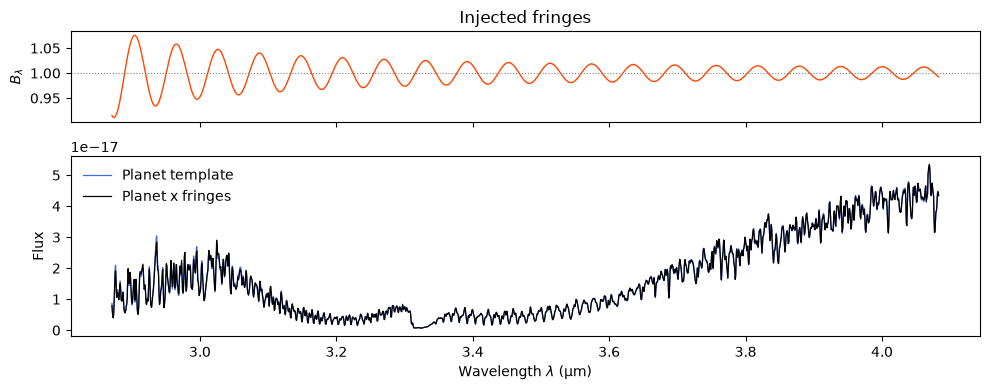

In [115]:
FRINGE_AMPLITUDE = 0.12
FRINGE_PERIOD_PIX = 90.0
FRINGE_SINC_SCALE = 1        # sinc damping at short wavelength
FRINGE_SINC_SCALE_LONG = 10.0    # stronger damping at long wavelength
FRINGE_SUPERSAMPLE = 10


def _sinc_smooth(signal: np.ndarray, sinc_scale: float, supersample: int) -> np.ndarray:
    half_width = int(4.0 * sinc_scale * supersample)
    kernel_x = np.arange(-half_width, half_width + 1, dtype=float)
    kernel = np.sinc(kernel_x / (sinc_scale * supersample))
    kernel /= kernel.sum()
    return np.convolve(signal, kernel, mode="same")


def build_ifu_fringes(
    wavelength: np.ndarray,
    amplitude: float = FRINGE_AMPLITUDE,
    period_pix: float = FRINGE_PERIOD_PIX,
    sinc_scale: float = FRINGE_SINC_SCALE,
    sinc_scale_long: float = FRINGE_SINC_SCALE_LONG,
    supersample: int = FRINGE_SUPERSAMPLE,
) -> np.ndarray:
    dlam = float(np.median(np.diff(wavelength)))
    period_um = period_pix * dlam
    pad_pix = int(4.0 * sinc_scale_long * supersample)
    wl_min = wavelength.min() - pad_pix * dlam / supersample
    wl_max = wavelength.max() + pad_pix * dlam / supersample
    n_fine = (wavelength.size - 1) * supersample + 1 + 2 * pad_pix
    wl_fine = np.linspace(wl_min, wl_max, n_fine)

    carrier = np.cos(2.0 * np.pi * (wl_fine - wl_fine[0]) / period_um)

    # Blend narrow (short-λ) and wide (long-λ) sinc kernels
    wl_norm = (wl_fine - wl_fine.min()) / (wl_fine.max() - wl_fine.min())
    mod_narrow = _sinc_smooth(carrier, sinc_scale, supersample)
    mod_wide = _sinc_smooth(carrier, sinc_scale_long, supersample)
    modulated = (1.0 - wl_norm) * mod_narrow + wl_norm * mod_wide
    modulated /= np.max(np.abs(mod_narrow))

    # Envelope: fringe contrast decreases with λ as sinc width increases
    scale_ratio = sinc_scale_long / sinc_scale
    visibility = 1.0 / (1.0 + wl_norm * (scale_ratio - 1.0))
    modulated *= visibility
    fringes_fine = 1.0 + amplitude * modulated
    return np.interp(wavelength, wl_fine, fringes_fine)


fringes = build_ifu_fringes(wavelength)
data_fringed = planet_template * fringes

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True, gridspec_kw={"height_ratios": [1, 2]})
axes[0].plot(wavelength, fringes, color="orangered", lw=1.0)
axes[0].axhline(1.0, color="gray", ls=":", lw=0.8)
axes[0].set_ylabel(r"$B_\lambda$")
axes[0].set_title(
    f"Injected fringes"
)

axes[1].plot(wavelength[finite], planet_template[finite], color="royalblue", lw=0.9, label="Planet template")
axes[1].plot(wavelength[finite], data_fringed[finite], color="k", lw=0.9, label="Planet x fringes")
axes[1].set_xlabel(r"Wavelength $\lambda$ (µm)")
axes[1].set_ylabel("Flux")
axes[1].legend(loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

## 3. Forward-model the fringed planet

We build spline components that modulate the planet template. A single linear combination fits the fringed data:

$$F_\mathrm{model}(\lambda) = \sum_j \phi_j\, B_j(\lambda)\, F_\mathrm{planet}(\lambda)$$

The spline envelope absorbs the IFU fringes; no separate planet amplitude is needed because the planet shape is already in the reference spectrum.

In [111]:
n_knots = 50
inverse_variance = np.ones_like(data_fringed)

spline_components = SplineModel(n_knots=n_knots)(planet_template)
amplitudes = solve_linear(data_fringed, inverse_variance, spline_components)
forward_model = amplitudes @ spline_components

fit_rms = np.sqrt(np.mean((data_fringed[finite] - forward_model[finite]) ** 2))
print(f"Forward-model RMS: {fit_rms:.3e}")

Forward-model RMS: 9.588e-20


## 4. Recovery diagnostics

Decompose the fit against each injected component:

- **Fringe model:** $B_\mathrm{rec}(\lambda) = F_\mathrm{model} / F_\mathrm{planet}$, compared to the injected $B_\lambda$.
- **Planet after fringe removal:** $F_\mathrm{planet,rec} = F_\mathrm{data} / B_\mathrm{rec}$, compared to the input planet template.
- **Planet residual:** $F_\mathrm{planet,rec} - F_\mathrm{planet}$.

In [112]:
safe_planet = np.where(np.abs(planet_template) > 0, planet_template, np.nan)

with np.errstate(divide="ignore", invalid="ignore"):
    recovered_fringes = forward_model / safe_planet
    planet_after_fringes = data_fringed / recovered_fringes

fringe_mask = finite & np.isfinite(recovered_fringes)
planet_mask = finite & np.isfinite(planet_after_fringes)

fringe_rms = np.sqrt(np.mean((recovered_fringes[fringe_mask] - fringes[fringe_mask]) ** 2))
planet_residual = planet_after_fringes[planet_mask] - planet_template[planet_mask]
planet_rms = np.sqrt(np.mean(planet_residual ** 2))

print(f"Fringe recovery RMS: {fringe_rms:.3e}")
print(f"Planet residual RMS (after fringe removal): {planet_rms:.3e}")

Fringe recovery RMS: 7.440e-03
Planet residual RMS (after fringe removal): 9.753e-20


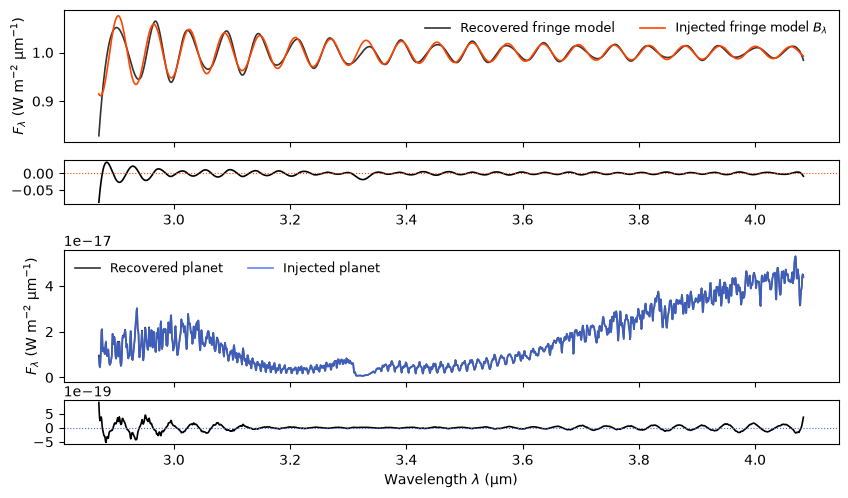

In [ ]:
wl = wavelength[finite]
lw = 1.2

fig, axes = plt.subplots(6,1,figsize=(10,6), gridspec_kw={"height_ratios": [3,1,0.2]*2, "hspace": 0.3})

ax_fringe_spec = axes[0]
ax_fringe_residuals = axes[1]
ax_fringe_empty = axes[2]

ax_fringe_spec.plot(wl,recovered_fringes[finite], color="k", lw=lw, alpha=0.8, label="Recovered fringe model")
ax_fringe_spec.plot(wl, fringes[finite], color="orangered", lw=lw, label="Injected fringe model $B_\\lambda$")
ax_fringe_residuals.plot(wl, recovered_fringes[finite] - fringes[finite], color="k", lw=lw)
ax_fringe_residuals.axhline(0.0, color="orangered", ls=":", lw=0.8)
ax_fringe_empty.set_axis_off()

ax_fringe_spec.legend(loc="upper right", frameon=False, ncol=3, fontsize=9)
plt.setp(ax_fringe_spec.get_xticklabels(), visible=False)

ax_planet_spec = axes[3]
ax_planet_residuals = axes[4]
ax_planet_empty = axes[5]

ax_planet_spec.plot(wl,planet_after_fringes[finite], color="k", lw=lw, alpha=0.8, label="Recovered planet")
ax_planet_spec.plot(wl, planet_template[finite], color="royalblue", lw=lw, label="Injected planet", alpha=0.8)
ax_planet_residuals.plot(wl, planet_after_fringes[finite] - planet_template[finite], color="k", lw=lw)
ax_planet_residuals.axhline(0.0, color="royalblue", ls=":", lw=0.8)
ax_planet_empty.set_axis_off()

ax_planet_spec.legend(loc="upper left", frameon=False, ncol=3, fontsize=9)
ax_planet_residuals.set_xlabel(r"Wavelength $\lambda$ (µm)")
plt.setp(ax_planet_spec.get_xticklabels(), visible=False)

ylabel = r"$F_\lambda$ (W m$^{-2}$ µm$^{-1}$)"
ax_fringe_spec.set_ylabel(ylabel)
ax_planet_spec.set_ylabel(ylabel)
fig_path = Path("../plots/fit_fringing_diagnostics.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()



The fringing model is recovered successfully when the frequency of the fringes is lower than the typical spectral features of the planet. When the frequencies (i.e. spacing) are comparable, it is challenging to disentangle the signals as seen around the strong CH4 band at 3.3 µm.

## Summary

- IFU fringes were injected multiplicatively on the planet template only (no starlight).
- A **single** spline-modulated planet term fits the fringed data; a separate planet amplitude is redundant.
- The recovered fringe model is $F_\mathrm{model} / F_\mathrm{planet}$; dividing the data by it restores the planet spectrum.
- Change `DETECTOR = 2` above to repeat on NRS2, or tune `FRINGE_PERIOD_PIX` and `n_knots`.
- For starlight + fringes + companion, see [`high_contrast_specroscopy_speckles.py`](high_contrast_specroscopy_speckles.py).
- For continuum normalization on real M-dwarf data, see [`fit_continuum.ipynb`](fit_continuum.ipynb).